## Optimizing Data Center Rack Layout
### 1. Global Setup and Visualization Engine
First, we define the environment constants and a robust plotting function that will be reused for all three cases.

In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Inputs
N_RACKS = 8
ROOM_SIZE = 5 # 5 m x 5 m
T_TARGET = 25          # Target temperature (Celsius)
T_CRAC = 18            # Ambient cooling air
Q_AVG = 8.0            # Heat per rack (kW)
ALPHA = 300            # Thermal penalty weight
BETA = 0.8             # Thermal penalty steepness
ELEC_WEIGHT = 2.0      # Weight for distance to center
GRID_WEIGHT = 40       # Weight for snapping to tiles
POP_SIZE = 100
GENERATIONS = 150

def plot_layout(layout, title, ax):
    """Utility to draw the room, racks, and orientations."""
    coords = layout.reshape((N_RACKS, 3))
    ax.set_xlim(0, ROOM_SIZE)
    ax.set_ylim(0, ROOM_SIZE)
    ax.set_title(title)
    ax.set_aspect('equal')
    
    for i in range(N_RACKS):
        x, y, ang = coords[i]
        rad = np.radians(ang)
        # Body
        rect = patches.Rectangle((x-0.4, y-0.4), 0.8, 0.8, color='gray', alpha=0.4, ec='black')
        ax.add_patch(rect)
        # Intake (Blue Arrow)
        ax.arrow(x, y, np.cos(rad)*0.5, np.sin(rad)*0.5, head_width=0.2, color='blue', alpha=0.8)
        # Exhaust (Red Dot)
        ax.plot(x - np.cos(rad)*0.4, y - np.sin(rad)*0.4, 'ro', markersize=4)
    
    ax.grid(True, linestyle=':', alpha=0.6)

# GENETIC ALGORITHM
def crossover(p1, p2):
    pt = random.randint(1, len(p1)-1)
    return np.concatenate([p1[:pt], p2[pt:]])

def mutate(ind, rate=0.15):
    for i in range(len(ind)):
        if random.random() < rate:
            if i % 3 == 2: ind[i] = random.uniform(0, 360) # Angle
            else: ind[i] = random.uniform(0.5, ROOM_SIZE-0.5) # Position
    return ind

def run_evolution(fitness_func):
    """Standard loop to evolve a population based on a specific fitness function."""
    pop = [np.array([random.uniform(0.5, ROOM_SIZE-0.5) if i%3!=2 else random.uniform(0, 360) 
                     for i in range(N_RACKS*3)]) for _ in range(POP_SIZE)]
    
    for gen in range(GENERATIONS):
        evals = sorted([(ind, fitness_func(ind)) for ind in pop], key=lambda x: x[1], reverse=True)
        next_gen = [x[0] for x in evals[:10]] # Elitism
        while len(next_gen) < POP_SIZE:
            p1, p2 = random.sample(next_gen[:20], 2)
            next_gen.append(mutate(crossover(p1, p2)))
        pop = next_gen
    return pop[0] # Return best individual

### Step 1: Connectivity vs. Physical Space
**Markdown Description:**
In this first model, we ignore heat entirely. We optimize for the shortest cables ($J_{elec}$) and ensure racks don't occupy the same physical space ($J_{overlap}$). 
**Formula:** $J = w_e J_{elec} + J_{overlap}$

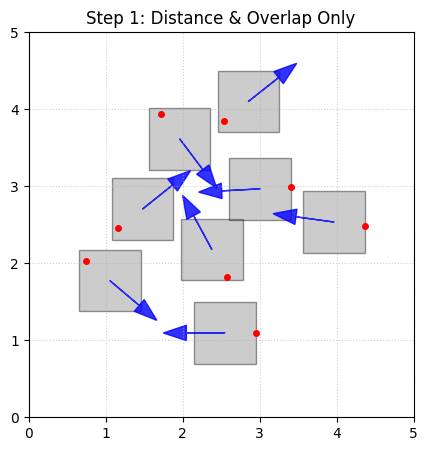

In [2]:
def fitness_step_1(layout):
    coords = layout.reshape((N_RACKS, 3))
    # Electrical: Manhattan distance to center
    j_elec = np.sum(np.abs(coords[:, :2] - ROOM_SIZE/2))
    # Overlap: Penalty for centers closer than 1m
    j_overlap = 0
    for i in range(N_RACKS):
        for j in range(i + 1, N_RACKS):
            if np.linalg.norm(coords[i,:2] - coords[j,:2]) < 1.0:
                j_overlap += 1000
    return 1.0 / (ELEC_WEIGHT * j_elec + j_overlap + 1)

best_1 = run_evolution(fitness_step_1)
fig, ax = plt.subplots(figsize=(5,5))
plot_layout(best_1, "Step 1: Distance & Overlap Only", ax)
plt.show()

### Step 2: Introducing Thermodynamics
**Markdown Description:**
We now add the thermal recirculation penalty. Racks must now manage their orientations ($\phi$) to prevent hot exhaust from entering neighbor intakes. 
**Formula:** $J = w_e J_{elec} + J_{overlap} + J_{therm}$

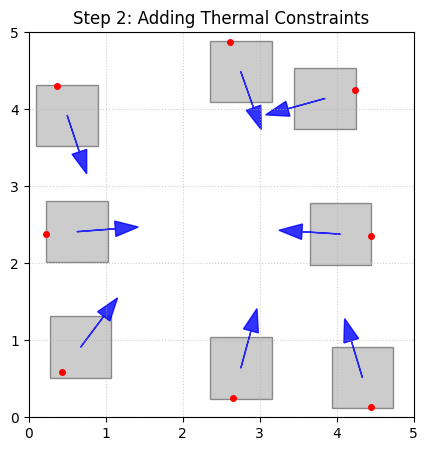

In [3]:
def fitness_step_2(layout):
    coords = layout.reshape((N_RACKS, 3))
    j_therm = 0
    for i in range(N_RACKS):
        temp_i = T_CRAC
        pos_i = coords[i, :2]
        for j in range(N_RACKS):
            if i == j: continue
            pos_j, ang_j = coords[j, :2], np.radians(coords[j, 2])
            vec_ji = pos_i - pos_j
            dist_ji = np.linalg.norm(vec_ji) + 0.5
            exhaust_vec_j = np.array([np.cos(ang_j + np.pi), np.sin(ang_j + np.pi)])
            alignment = max(0, np.dot(exhaust_vec_j, vec_ji / dist_ji))
            lambda_ji = (1.0 / dist_ji**2) * (1 + 5 * alignment)
            temp_i += lambda_ji * Q_AVG
        if temp_i > T_TARGET:
            j_therm += ALPHA * np.exp(BETA * (temp_i - T_TARGET))
    
    # Recalculate basic costs from Step 1
    cost_s1 = 1.0/fitness_step_1(layout) - 1
    return 1.0 / (cost_s1 + j_therm + 1)

best_2 = run_evolution(fitness_step_2)
fig, ax = plt.subplots(figsize=(5,5))
plot_layout(best_2, "Step 2: Adding Thermal Constraints", ax)
plt.show()


### Step 3: Structural Grid Alignment
**Markdown Description:**
Finally, we add the "Grid Snapping" penalty. This represents the real-world requirement of aligning racks with floor tiles and power tracks. This is where the **Hot/Cold Aisle** pattern emerges.
**Formula:** $J = w_e J_{elec} + J_{overlap} + J_{therm} + w_g J_{grid}$

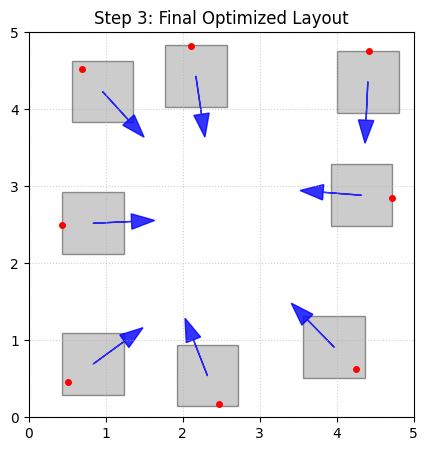

In [4]:
def fitness_step_3(layout):
    coords = layout.reshape((N_RACKS, 3))
    j_grid = 0
    for i in range(N_RACKS):
        # Position error from nearest 0.5m grid
        dx = abs(coords[i, 0] - round(coords[i, 0] * 2) / 2)
        dy = abs(coords[i, 1] - round(coords[i, 1] * 2) / 2)
        # Angle error from nearest 90-degree cardinal
        da = abs(coords[i, 2] - round(coords[i, 2] / 90) * 90) / 90
        j_grid += (dx + dy + da) * GRID_WEIGHT
    
    cost_s2 = 1.0/fitness_step_2(layout) - 1
    return 1.0 / (cost_s2 + j_grid + 1)

best_3 = run_evolution(fitness_step_3)
fig, ax = plt.subplots(figsize=(5,5))
plot_layout(best_3, "Step 3: Final Optimized Layout", ax)
plt.show()

### Step 4: Penalize hot air being blown at cold inlets

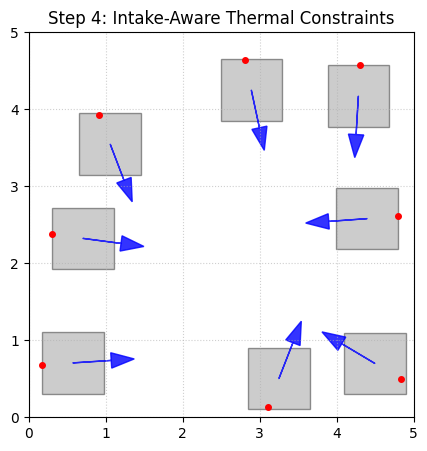

In [5]:
def fitness_step_4(layout):
    coords = layout.reshape((N_RACKS, 3))
    j_therm = 0
    for i in range(N_RACKS):
        temp_i = T_CRAC
        pos_i = coords[i, :2]
        ang_i = np.radians(coords[i, 2])
        # Unit vector for the intake of rack i
        intake_vec_i = np.array([np.cos(ang_i), np.sin(ang_i)])
        
        for j in range(N_RACKS):
            if i == j: continue
            pos_j, ang_j = coords[j, :2], np.radians(coords[j, 2])
            
            vec_ji = pos_i - pos_j
            dist_ji = np.linalg.norm(vec_ji) + 0.5
            unit_vec_ji = vec_ji / (np.linalg.norm(vec_ji) + 1e-6)
            
            # 1. Exhaust Alignment: Is j blowing towards i?
            # (Exhaust is 180 deg from intake)
            exhaust_vec_j = np.array([np.cos(ang_j + np.pi), np.sin(ang_j + np.pi)])
            exh_align = max(0, np.dot(exhaust_vec_j, unit_vec_ji))
            
            # 2. Intake Alignment: Is rack i's intake facing the source j?
            # (We use -unit_vec_ji because we want to see if intake points BACK at j)
            int_align = max(0, np.dot(intake_vec_i, -unit_vec_ji))
            
            # Combine: Heat transfer is highest when j blows at i AND i's intake is facing j
            # The (1 + int_align) term doubles the impact if it hits the intake directly
            lambda_ji = (1.0 / dist_ji**2) * (1 + 5 * exh_align * (1 + int_align))
            temp_i += lambda_ji * Q_AVG
            
        if temp_i > T_TARGET:
            j_therm += ALPHA * np.exp(BETA * (temp_i - T_TARGET))
    
    # Recalculate basic costs from Step 1
    cost_s1 = 1.0/fitness_step_1(layout) - 1
    return 1.0 / (cost_s1 + j_therm + 1)

# Run evolution with the new intake-aware logic
best_4 = run_evolution(fitness_step_4)
fig, ax = plt.subplots(figsize=(5,5))
plot_layout(best_4, "Step 4: Intake-Aware Thermal Constraints", ax)
plt.show()

In [6]:
def evaluate_and_export(best_individual):
    # Reshape the flat GA chromosome into [x, y, angle]
    coords = best_individual.reshape((N_RACKS, 3))
    
    print("\n--- FINAL THERMAL VERIFICATION ---")
    rack_temps = []
    
    # We calculate the temperatures exactly as the fitness function does
    for i in range(N_RACKS):
        temp_i = T_CRAC
        pos_i = coords[i, :2]
        for j in range(N_RACKS):
            if i == j: continue
            pos_j, ang_j = coords[j, :2], np.radians(coords[j, 2])
            vec_ji = pos_i - pos_j
            dist_ji = np.linalg.norm(vec_ji) + 0.5
            
            # Exhaust vector (180 degrees from the intake blue arrow)
            exhaust_vec_j = np.array([np.cos(ang_j + np.pi), np.sin(ang_j + np.pi)])
            
            alignment = max(0, np.dot(exhaust_vec_j, vec_ji / dist_ji))
            lambda_ji = (1.0 / dist_ji**2) * (1 + 5 * alignment)
            temp_i += lambda_ji * Q_AVG
        
        rack_temps.append(temp_i)
        status = "OK" if temp_i <= T_TARGET else "OVERHEAT"
        print(f"Rack {i}: {temp_i:.2f}°C [{status}]")

    print(f"\nMax Room Temp: {max(rack_temps):.2f}°C")
    
    # Generate the Copy-Paste string
    layout_string = ",".join([f"{x:.2f}" for x in best_individual])
    print("\n--- COPY AND PASTE THE LINE BELOW ---")
    print(layout_string)
    print("--------------------------------------")

# check
print("------------ best_1 ------------ ")
evaluate_and_export(best_1)

print("------------ best_2 ------------ ")
evaluate_and_export(best_2)

print("------------ best_3 ------------ ")
evaluate_and_export(best_3)

print("------------ best_4 ------------ ")
evaluate_and_export(best_4)

------------ best_1 ------------ 

--- FINAL THERMAL VERIFICATION ---
Rack 0: 40.93°C [OVERHEAT]
Rack 1: 39.45°C [OVERHEAT]
Rack 2: 45.36°C [OVERHEAT]
Rack 3: 41.30°C [OVERHEAT]
Rack 4: 42.20°C [OVERHEAT]
Rack 5: 30.16°C [OVERHEAT]
Rack 6: 43.95°C [OVERHEAT]
Rack 7: 42.05°C [OVERHEAT]

Max Room Temp: 45.36°C

--- COPY AND PASTE THE LINE BELOW ---
2.55,1.10,180.18,2.38,2.18,118.41,1.96,3.62,306.94,3.01,2.97,183.05,1.05,1.78,319.80,2.85,4.10,38.27,3.97,2.54,172.17,1.48,2.70,38.69
--------------------------------------
------------ best_2 ------------ 

--- FINAL THERMAL VERIFICATION ---
Rack 0: 24.65°C [OK]
Rack 1: 24.32°C [OK]
Rack 2: 24.18°C [OK]
Rack 3: 24.38°C [OK]
Rack 4: 24.73°C [OK]
Rack 5: 23.66°C [OK]
Rack 6: 24.41°C [OK]
Rack 7: 24.73°C [OK]

Max Room Temp: 24.73°C

--- COPY AND PASTE THE LINE BELOW ---
2.75,4.49,289.46,4.33,0.52,106.76,2.76,0.64,74.82,4.05,2.38,176.44,0.63,2.41,4.35,0.50,3.92,288.47,0.68,0.91,53.15,3.85,4.14,195.45
--------------------------------------
------

In [7]:
# --- PHYSICAL FEASIBILITY CHECK ---
rho = 1.225      # Density of air (kg/m3)
cp = 1.006       # Specific heat of air (kJ/kg*K)
delta_T = 10     # Typical temp difference between supply and return

total_heat_kw = N_RACKS * Q_AVG
# First Law: Q = m_dot * cp * delta_T
required_mass_flow = total_heat_kw / (cp * delta_T)
required_volume_flow = required_mass_flow / rho

print(f"Total Heat Load: {total_heat_kw} kW")
print(f"Required Airflow: {required_volume_flow:.2f} m3/s")

Total Heat Load: 64.0 kW
Required Airflow: 5.19 m3/s
